# LAB1

> HAIL `Level 3` : In this Laboratory, I use `ChatGPT` to help me to correct the code.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Project 1: Grey Image

### 1-1: Generate a 256 $\times$ 256 image with gray level from 0 to 255.

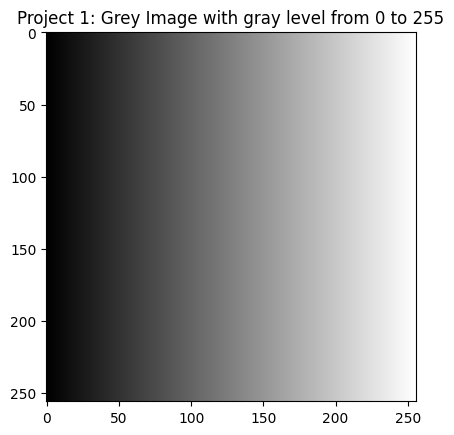

In [2]:
# set the height and width of the grey image
height, width = 256, 256

# init the grey image
linear_gradient = np.fromfunction(lambda i, j: j, (height, width), dtype=np.uint8)

# show image
plt.figure()
plt.imshow(linear_gradient, cmap='gray', vmin=0, vmax=255)
plt.title("Project 1: Grey Image with gray level from 0 to 255")
plt.show()

### 1-2: Generate a 256 $\times$ 256 image with gray level from 0 to 255 and each band being 16 pixels wide and increasing in value by a step of 16.

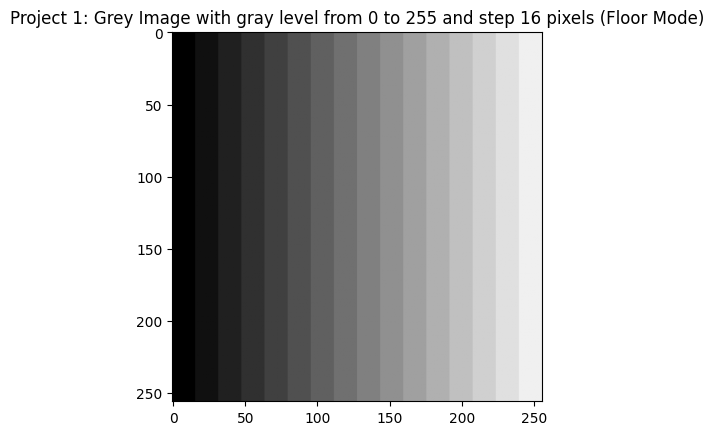

In [3]:
# init the grey image (Floor Mode)
step_gradient = np.fromfunction(lambda i, j: (j // 16) * 16, (height, width), dtype=np.uint8)

# show image
plt.figure()
plt.imshow(step_gradient, cmap='gray', vmin=0, vmax=255)
plt.title("Project 1: Grey Image with gray level from 0 to 255 and step 16 pixels (Floor Mode)")
plt.show()

对于图像的量化来说，可以选取不同的量化规则得到不同的图像。上面采用了 `floor` 的逻辑量化灰度图，即用函数 `lambda i, j: (j // 16) * 16` 将范围内的灰度值都取为该范围的最小值。同样，我们也可以尝试采用不同的量化逻辑。下面就采用了 `ceil` 的逻辑实现灰度图的量化。采用 `lambda i, j: (j // 16 + 1) * 16 - 1` 实现灰度量化。

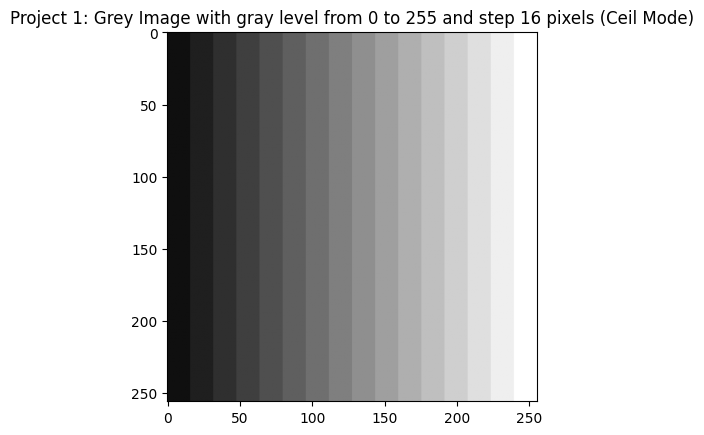

In [4]:
# init the grey image
step_gradient_ceil = np.fromfunction(lambda i, j: (j // 16 + 1) * 16 - 1, (height, width), dtype=np.uint8)

# show image
plt.figure()
plt.imshow(step_gradient_ceil, cmap='gray', vmin=0, vmax=255)
plt.title("Project 1: Grey Image with gray level from 0 to 255 and step 16 pixels (Ceil Mode)")
plt.show()

从输出的图片能够大致观察出两图的差别，但是还不够明显。因此对比相同位置的灰度值，更明显地观察差异。

In [5]:
print("\t\t Step Image (Floor) \t Step Image (Ceil) \n")
print(f"Size \t\t {step_gradient.shape} \t\t {step_gradient_ceil.shape} \n")
print(f"(0, 0) \t\t {step_gradient[0, 0]} \t\t\t {step_gradient_ceil[0, 0]} \n")
print(f"(15, 15) \t {step_gradient[15, 15]} \t\t\t {step_gradient_ceil[15, 15]} \n")
print(f"(255, 255) \t {step_gradient[255, 255]} \t\t\t {step_gradient_ceil[255, 255]} \n")

		 Step Image (Floor) 	 Step Image (Ceil) 

Size 		 (256, 256) 		 (256, 256) 

(0, 0) 		 0 			 15 

(15, 15) 	 0 			 15 

(255, 255) 	 240 			 255 



从如上输出可以看出，对原图中的任意一点，按照 `Ceil` 量化逻辑得到的图像灰度值都比 `Floor` 大 `15` 。

## Project 2: Intensity Levels

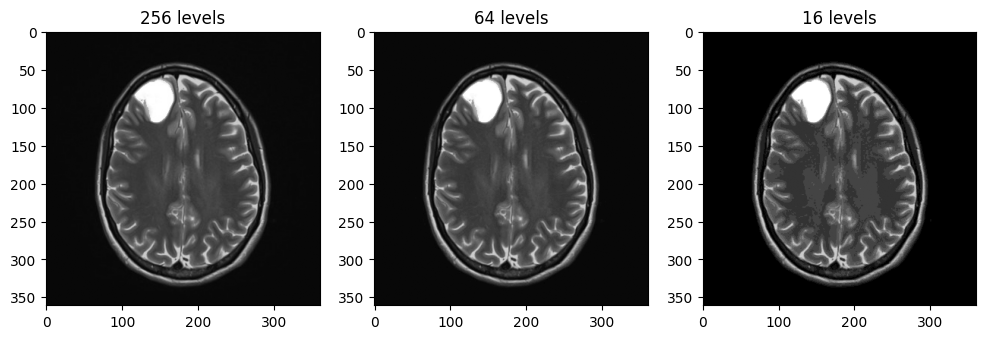

In [6]:
def reduce_level(img_origin, n):
    """reduce the grey level

    Args:
        img_origin (arr): original image
        n (integer): reduce to 2^n

    Returns:
        arr: image with reduction of the grey scale level 2^n
    """
    levels = 2 ** n
    step = 256 / levels
    img_result = np.floor(img / step)
    return img_result

# read the image
img = np.load('./input/lab1.npy')

# set value
n_values = [8, 6, 4]
img_results = []

# reduce the grey level
for i in range(len(n_values)):
    img_results.append(reduce_level(img, n_values[i]))
    
# show the images
fig, axes = plt.subplots(1, len(n_values), figsize=(4*len(n_values), 4))
for i in range(len(n_values)):
    vmax = 2 ** n_values[i] - 1
    axes[i].imshow(img_results[i], cmap="grey", vmin=0, vmax=vmax)
    axes[i].set_title(f"{2 ** n_values[i]} levels")
plt.show()

观察以上三幅图，对于 8 阶灰度图和 6 阶灰度图，人眼还略微难以观察出区别。但是最右边的 4 阶灰度图可以明显看出大脑中间部分有明显的分层效果。

## Project 3: Zooming and Shrinking Images

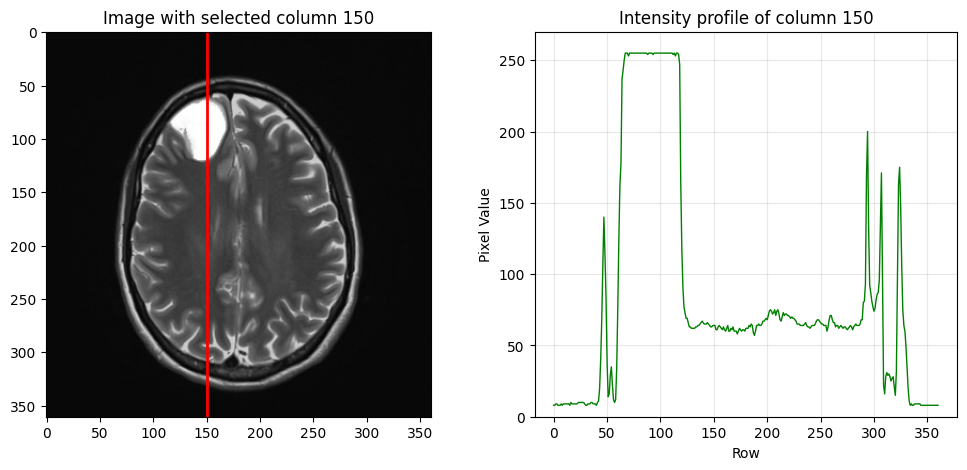

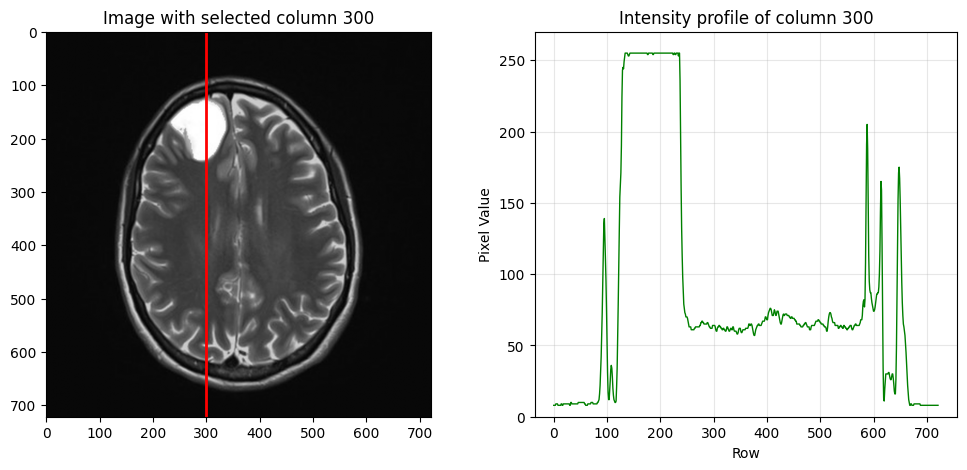

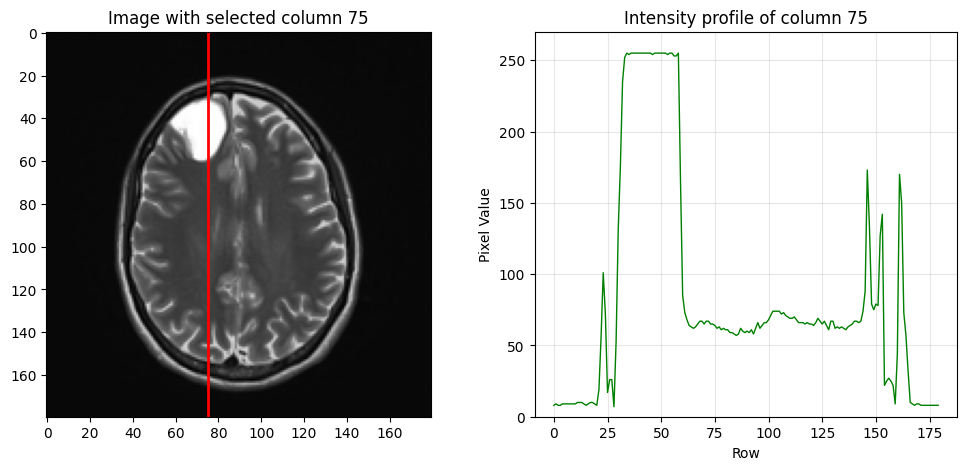

In [7]:
def zoom_image(img_origin, factor):
    """zoom the image

    Args:
        img_origin (arr): original image
        factor (integer): parameter of zoom
        
    Return:
        img_zoom: image after zooming
    """
    pil_img = Image.fromarray(img_origin)
    new_size = (int(img_origin.shape[1] * factor), int(img_origin.shape[0] * factor))
    pil_zoom = pil_img.resize(new_size, Image.Resampling.LANCZOS)
    img_zoom = np.array(pil_zoom)
    return img_zoom

def plot_line(img, number, axis):
    """plot the line in the img

    Args:
        img (arr): original image
        number (integer): the number of select row or column
        axis (integer): 0 for rows and 1 for columns
    """
    # init figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    if axis == 0:  # row line
        # original image with line
        ax1.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax1.axhline(y=number, color='r', linewidth=2)
        ax1.set_title(f'Image with selected row {number}')
        
        # plot figure of values in line
        line_values = img[number, :]
        ax2.plot(line_values, 'b-', linewidth=1)
        ax2.set_title(f'Intensity profile of row {number}')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Pixel Value')
        ax2.set_ylim(0, 270)
        ax2.grid(True, alpha=0.3)
        
    elif axis == 1:  # column line
        # original image with line
        ax1.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax1.axvline(x=number, color='r', linewidth=2)
        ax1.set_title(f'Image with selected column {number}')
        
        # plot figure of values in line
        line_values = img[:, number]
        ax2.plot(line_values, 'g-', linewidth=1)
        ax2.set_title(f'Intensity profile of column {number}')
        ax2.set_xlabel('Row')
        ax2.set_ylabel('Pixel Value')
        ax2.set_ylim(0, 270)
        ax2.grid(True, alpha=0.3)
    
    plt.show()
    
# original image
number = 150
plot_line(img, number=number, axis=1)
# zoomed image
# 2
factor = 2
img_zoom = zoom_image(img, factor)
plot_line(img_zoom, number=number*factor, axis=1)
# 1 / 2
factor = 1 / 2
img_zoom = zoom_image(img, factor)
plot_line(img_zoom, number=int(number*factor), axis=1)

以上代码将原图分别放大到原来的 2 倍和 $\frac 1 2$ 倍，并选择原图的第 150 列为分割线，将分割线上的数据绘制在了右侧。可以看到当图像放大（或缩小）后，想要在相同位置切割，需要将对应的列值也放大（或缩小）。由于缩放的比例不是很大，缩放的结果没法明显地呈现，改变 `factor` 的取值。

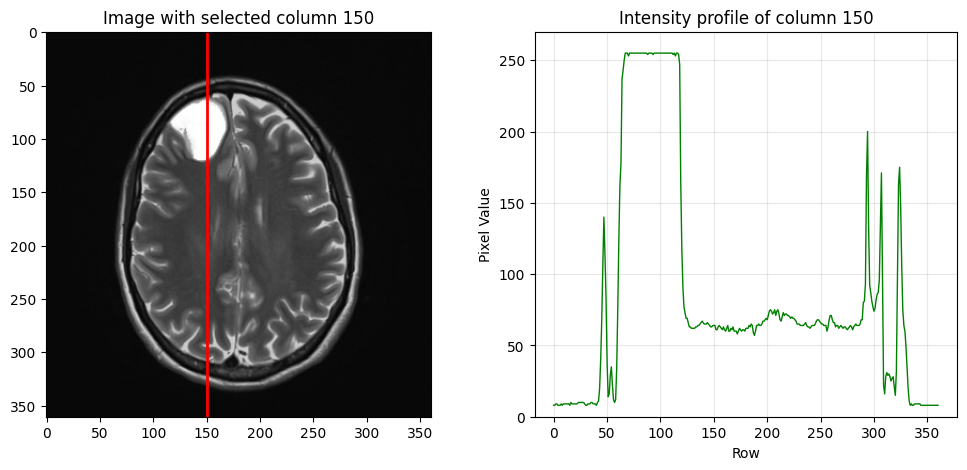

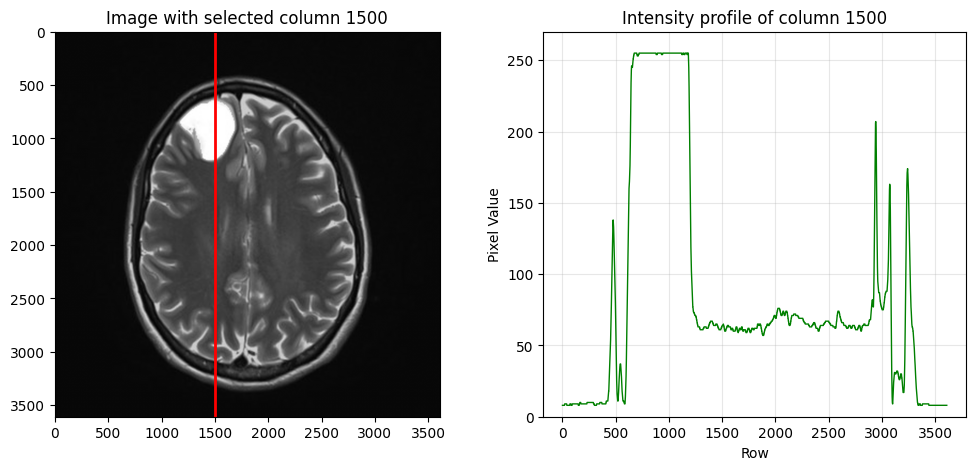

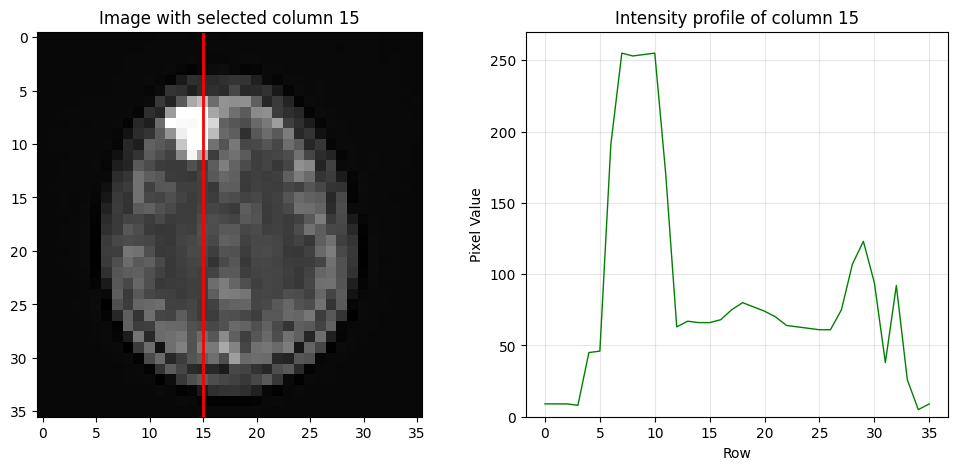

In [8]:
# original image
number = 150
plot_line(img, number=number, axis=1)
# zoomed image
# 10
factor = 10
img_zoom = zoom_image(img, factor)
plot_line(img_zoom, number=number*factor, axis=1)
# 1 / 10
factor = 1 / 10
img_zoom = zoom_image(img, factor)
plot_line(img_zoom, number=int(number*factor), axis=1)

将缩放因数 `factor` 分别增大和缩小后，可以清晰地看到缩放对图像的影响。尤其是缩小了较大倍数后，整张图像的细节消失殆尽，对应切割位置的值的曲线，也逐渐平滑，图像丢失了大量的细节信息。

## Project 4: Color overlay

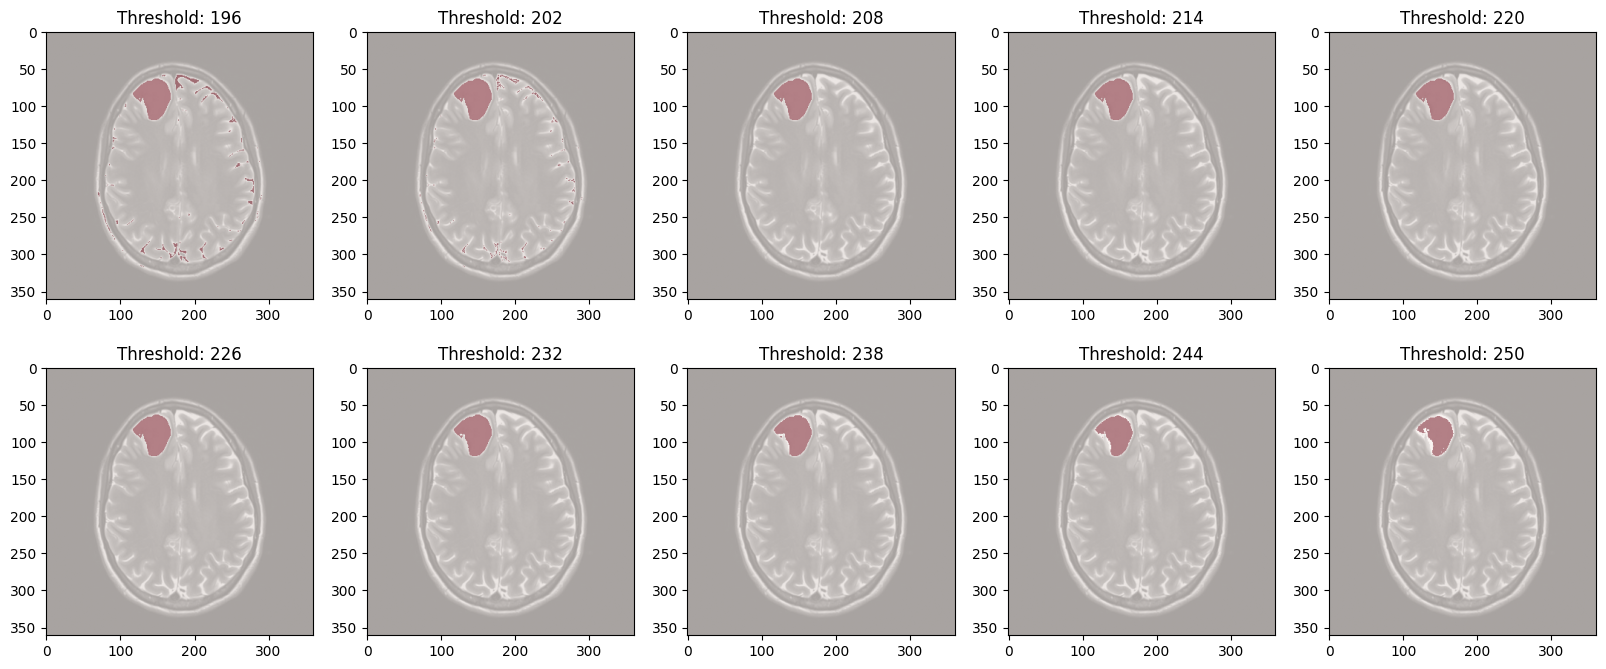

In [9]:
def generate_mask(img, threshold):
    """generate the mask of image(keep the part larger than threshold)

    Args:
        img (arr): oringinal iamge
        threshold (integer): threhold
        
    Return:
        mask(arr): the part larger than threshold
    """
    mask = img > threshold
    return mask

rows = 2
columns = 5
step = 6
threshold_values = range(256 - rows*columns*step, 256, step)
fig, axes = plt.subplots(rows, columns, figsize=(4*columns, 4*rows))
for i in range(rows):
    for j in range(columns): 
        threshold = threshold_values[i * columns + j]
        mask = generate_mask(img, threshold)
        axes[i][j].imshow(img, cmap='gray', vmin=0, vmax=255, alpha=0.7)
        axes[i][j].imshow(mask, cmap='Reds', alpha=0.5)
        axes[i][j].set_title(f"Threshold: {threshold}")
plt.show()

根据以上代码，简单筛选了不同阈值 `threshold` 下，`mask` 对应的区域。可以发现：当 `threshold <= 202` 的时候，会将部分右脑也包含到 `maks` 之中，因此对 `threshold` 在 202 和 208 之间的图像进行进一步的筛选。

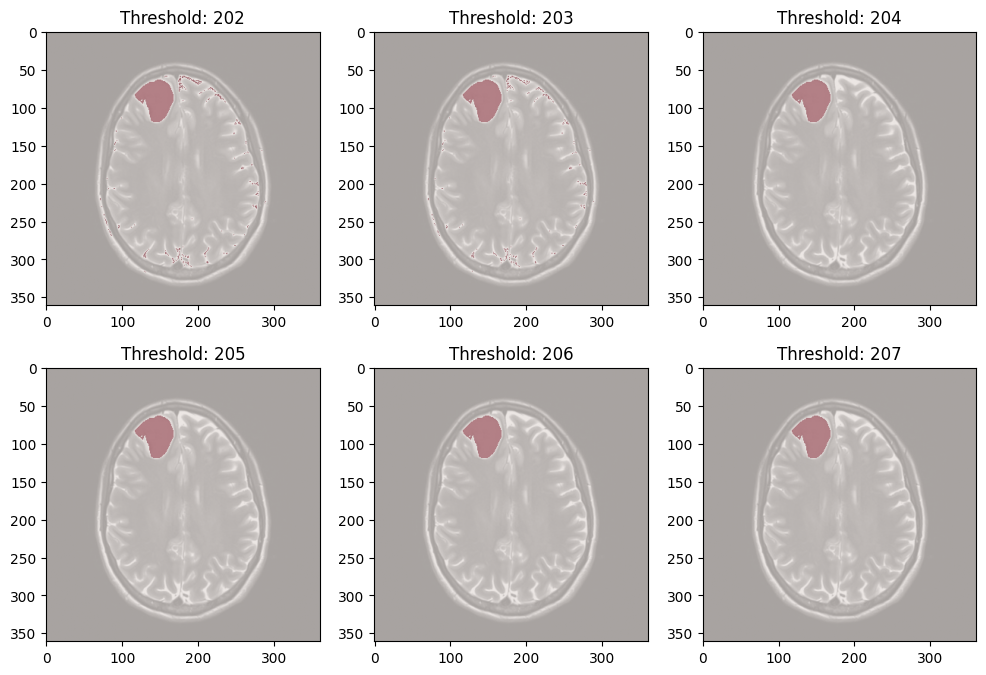

In [10]:
rows = 2
columns = 3
step = 1
threshold_values = range(208 - rows*columns*step, 208, step)
fig, axes = plt.subplots(rows, columns, figsize=(4*columns, 4*rows))
for i in range(rows):
    for j in range(columns): 
        threshold = threshold_values[i * columns + j]
        mask = generate_mask(img, threshold)
        axes[i][j].imshow(img, cmap='gray', vmin=0, vmax=255, alpha=0.7)
        axes[i][j].imshow(mask, cmap='Reds', alpha=0.5)
        axes[i][j].set_title(f"Threshold: {threshold}")
plt.show()

根据以上这组图像，可以发现 `threshold` 的临界值在 203 到 204 之间。其中，阈值 `threshold = 203` 时还是出现了错误，因此选定阈值 `threshold = 204`。但是根据以上透明度的方式叠加图片会让图片清晰度大大下降，因此需要优化涂层叠加的函数。

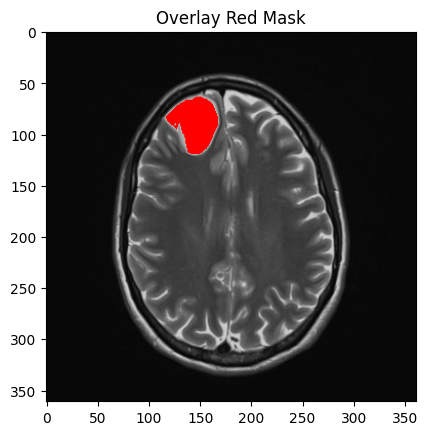

In [11]:
def generate_mask(img, threshold):
    """generate the mask of image(keep the part larger than threshold)

    Args:
        img (arr): oringinal iamge
        threshold (integer): threhold
        
    Return:
        mask(arr): the part larger than threshold
    """
    mask = img > threshold
    return mask

def overlay_mask(img, mask):
    """cover the Red Mask above the original image"""
    
    height, width = img.shape
    img_result = np.zeros((height, width, 3), dtype=np.uint8)
    
    # add original image
    for i in range(3):
        img_result[~mask, i] = img[~mask]
        
    # add red mask
    img_result[mask] = [255, 0, 0]
    
    return img_result

# set threshold
threshold = 204

# generate mask
mask = generate_mask(img, threshold)

# overlay the mask
img_result = overlay_mask(img, mask)

# show the figure
plt.imshow(img_result)
plt.title("Overlay Red Mask")
plt.show()

定义了图层叠加函数 `overlay_mask()` ，选定阈值 `threshold = 204` ，能够得出以上图像。 `mask` 基本完美包括了病变区域，实验完成。